# Feature Extraction

Data representation plays a critical role in the performance of many machine learning methods in machine learning. The data representation of network traffic often determines the effectiveness of these models as much as the model itself. The wide range of novel events that network operators need to detect (e.g., attacks, malware, new applications, changes in traffic demands) introduces the possibility for a broad range of possible models and data representations.

[NetML](https://pypi.org/project/netml/) is an open-source tool and end-to-end pipeline for anomaly detection in network traffic. This notebook walks through the use of that library.

First, let us load the library.

In [1]:
import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

from netml.pparser.parser import PCAP
from netml.utils.tool import dump_data, load_data

import pandas as pd

## Specify a Packet Capture File

Create a pcap data structure for which we would like to extract features. You could do this based on the packet capture files that we have been using in previous hands assignments. Any packet capture file will suffice, however.

You can define the minumum number of packets that you want to include in each flow.

In [10]:
pcap = PCAP('data/http.pcap', flow_ptks_thres=5, verbose=10)

## Convert the Packet Capture Into Flows

Find the function in `netml` that converts the pcap file into flows. Examing the resulting data structure. What does it contain?

In [12]:
pcap.pcap2flows()

pcap_file: data/http.pcap
ith_packets: 0
ith_packets: 10000
ith_packets: 20000
len(flows): 593
total number of flows: 593. Num of flows < 5 pkts: 354, and >=5 pkts: 239 without timeout splitting.
kept flows: 239. Each of them has at least 5 pkts after timeout splitting.
flow_durations.shape: (239, 1)
        col_0
count 239.000
mean   12.067
std    16.106
min     0.025
25%     0.126
50%     0.564
75%    20.215
max    45.073
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col_0   239 non-null    float64
dtypes: float64(1)
memory usage: 2.0 KB
None
0th_flow: len(pkts): 5
After splitting flows, the number of subflows: 239 and each of them has at least 5 packets.


## Explore the Flows

How many flows are in your data structure?

What other information does the flow data structure contain, for each flow?

593 flows, there is also summary stats, memory usage, and data type.

## Extract Features from Each Flow

Use the `netml` library to extract features from each flow. 

The [documentation](https://pypi.org/project/netml/) and [accompanying paper](https://arxiv.org/pdf/2006.16993.pdf) provide examples of features that you can try to extract. 

First try to extract the inter-arrival times for each flow.

### Interarrival Times

In [17]:
pcap.flow2features('IAT', fft=False, header=False)

True


### Explore the Per-Flow Features

Inspect and print the features for each flow. (If you feel compelled: Get fancy! Plot distributions, etc. Whatever you like!)

In [28]:
iat_features = pcap.features

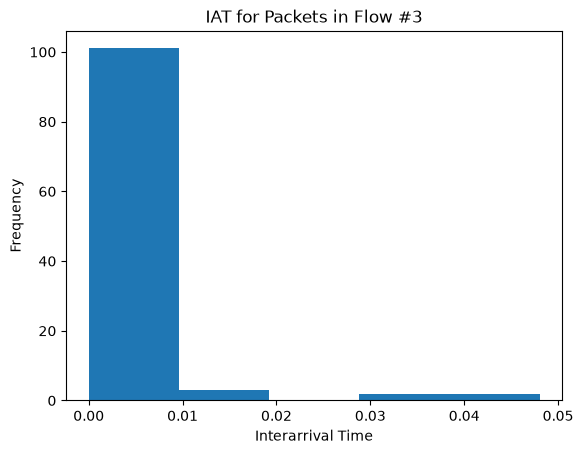

In [27]:
import matplotlib.pyplot as plt

plt.hist(pcap.features[2], bins=5)
plt.xlabel("Interarrival Time")
plt.ylabel("Frequency")
plt.title("IAT for Packets in Flow #3")
plt.show()

### Other Features and Options

1. Try some of the other features in the `netml` library.

  Here are some of the other possibilities, which can be passed to the library:
  * IAT: A flow is represented as a timeseries of inter-arrival times between packets, i.e., elapsed time in seconds between any two packets in the flow.   
  *  STATS: A flow is represented as a set of statistical quantities. We choose ten of the most common such
statistics in the literature: flow duration, number of packets sent per second, number of bytes
per second, and various statistics on packet sizes within each flow: mean, standard deviation, inter-quartile range,
minimum, and maximum.
  * SIZE: A flow is represented as a timeseries of packet sizes in bytes, with one sample per packet. 
  * SAMP-NUM: A flow is partitioned into small intervals of equal length 𝛿𝑡, and the number of packets in each interval is recorded; thus, a flow is represented as a timeseries of packet counts in small time intervals, with one sample per time interval. Here, 𝛿𝑡 might be viewed as a choice of sampling rate for the timeseries, hence the nomenclature.
  * SAMP-SIZE: A flow is partitioned into time intervals of equal length 𝛿𝑡, and the total packet size (i.e., byte count) in each interval is recorded; thus, a flow is represented as a timeseries of byte counts in small time intervals, with one sample per time interval.
  

In [29]:
pcap.flow2features('STATS', fft=False, header=False)
stats_features = pcap.features

True


In [30]:
pcap.flow2features('SIZE', fft=False, header=False)
size_features = pcap.features

True


In [35]:
import numpy as np
print(np.shape(iat_features))
print(np.shape(stats_features))
print(np.shape(size_features))

(239, 108)
(239, 12)
(239, 109)


  
2. One of the challenges with providing packet traces to models involve ensuring that all feature vectors are of the same length. The `netml` libary will do that for you, but there are a number of different ways to solve the problem. What do some of the following options do?  Explore how different settings of the following affect the dimensionality of your resulting feature vector.

 * flow_ptks_thres
 * q_interval

In [38]:
pcap_test = PCAP('data/http.pcap', flow_ptks_thres=3)

pcap_test.pcap2flows()

pcap_test.flow2features('IAT', fft=False, header=False)
iat_features_test = pcap_test.features

pcap.flow2features('STATS', fft=False, header=False)
stats_features_test = pcap_test.features

pcap.flow2features('SIZE', fft=False, header=False)
size_features_test = pcap_test.features

True
True


In [39]:
print(np.shape(iat_features_test))
print(np.shape(stats_features_test))
print(np.shape(size_features_test))

(276, 100)
(276, 100)
(276, 100)


## Thought Questions

What other features might you want to extract from packet captures that are not provided by the `netml` library?

Successful delivery, proportion of suspicious packets